### Project By- Pranali for DASA TECHNOWORLD PVT. LTD.

# Farm Performance Classification

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

sns.set_style("whitegrid")

In [2]:
# ============================================================
# Load Feature Engineered Dataset
# ============================================================

df = pd.read_csv("../data/processed/farm_ml_clean_data.csv")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (22917, 17)


,Farmer_ID,State,Farm_Size_Birds,Experience_Years,Join_Date,Contract_Type,Contract_Duration_Months,Expected_ROI_%,Total_Chicks,Total_Mortality,Total_Feed_Consumed,Total_Feed_Used_KG,Total_Feed_Cost,Total_Sales_Qty,Total_Revenue,Mortality_Rate,Profit
0,100000,UP,9042,8,2022-01-31,Revenue_Sharing,12.0,16.0,4104.0,33.0,4101.0,8100.0,255839.0,8191.0,817700.0,0.008041,396953.5
1,100001,Maharashtra,17015,2,2023-06-07,Revenue_Sharing,12.0,16.0,1178.0,101.0,12020.0,12871.0,368959.0,5592.0,675278.0,0.085739,396953.5
2,100002,Tamil Nadu,14906,14,2023-07-06,Buy_Back,12.0,12.0,3770.0,400.0,24500.0,8100.0,255839.0,10752.0,1012352.0,0.106101,396953.5
3,100003,Telangana,706,19,2025-10-27,Revenue_Sharing,12.0,16.0,1754.0,281.0,4722.0,25057.0,850025.0,5978.0,974851.0,0.160205,124826.0
4,100004,Maharashtra,8072,16,2024-06-15,Buy_Back,18.0,10.0,12844.0,318.0,21365.0,3166.0,51899.0,16567.0,1760982.0,0.024759,1709083.0


In [3]:
def assign_performance(row):
    if (
        row['Mortality_Rate'] < 5 and
        row['Expected_ROI_%'] >= 20 and
        row['Total_Revenue'] > row['Total_Feed_Cost']
    ):
        return "Excellent"
    elif (
        row['Mortality_Rate'] < 10 and
        row['Expected_ROI_%'] >= 10
    ):
        return "Good"
    else:
        return "Poor"

df['Performance_Label'] = df.apply(assign_performance, axis=1)

In [4]:
le = LabelEncoder()
df['Performance_Label_Encoded'] = le.fit_transform(df['Performance_Label'])

In [5]:
# ============================================================
# Load Features and Target
# ============================================================

import joblib
import pandas as pd

feature_cols = [
    'Farm_Size_Birds',
    'Experience_Years',
    'Total_Chicks',
    'Total_Mortality',
    'Total_Feed_Consumed',
    'Total_Sales_Qty',
    'Expected_ROI_%',
    'Mortality_Rate'
]

X = df[feature_cols]
y = df['Performance_Label_Encoded']


print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nFeatures Used:")
print(feature_cols)

Feature Matrix Shape : (22917, 8)
Target Shape : (22917,)

Features Used:
['Farm_Size_Birds', 'Experience_Years', 'Total_Chicks', 'Total_Mortality', 'Total_Feed_Consumed', 'Total_Sales_Qty', 'Expected_ROI_%', 'Mortality_Rate']


In [6]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 18333
Testing Samples: 4584


# Model Training & Comparison

In [7]:
# ============================================================
# Train Multiple Classification Models
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42, 
        n_estimators=200
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    )
}

results = []

print("="*70)
print("Model Training & Performance Comparison")
print("="*70)

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Create comparison table
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(results_df)

Model Training & Performance Comparison


C:\Users\Pranali Undre\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.972295,0.974595,0.972295,0.972931
1,XGBoost,0.971859,0.973288,0.971859,0.972318
2,Decision Tree,0.960951,0.960505,0.960951,0.960689
3,Logistic Regression,0.780759,0.763029,0.780759,0.764737


In [8]:
# ============================================================
# Select Best Model
# ============================================================

best_index = results_df["Accuracy"].idxmax()

best_model_name = results_df.loc[best_index, "Model"]

best_model = models[best_model_name]

best_accuracy = results_df.loc[best_index, "Accuracy"]

print("="*60)
print("Best Performing Model")
print("="*60)

print(f"Model    : {best_model_name}")
print(f"Accuracy : {best_accuracy:.4f}")

Best Performing Model
Model    : Random Forest
Accuracy : 0.9723


In [9]:
# ============================================================
# Hyperparameter Tuning - Random Forest
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, None]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

# Train directly on original features
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print(f"\nBest Cross Validation Accuracy: {grid_search.best_score_:.4f}")

Best Parameters:
{'max_depth': None, 'n_estimators': 100}

Best Cross Validation Accuracy: 0.9695


In [10]:
# ============================================================
# Evaluate Tuned Random Forest
# ============================================================

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("="*60)
print("Tuned Random Forest Performance")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Tuned Random Forest Performance
Accuracy : 0.9743
Precision: 0.9765
Recall   : 0.9743
F1 Score : 0.9749


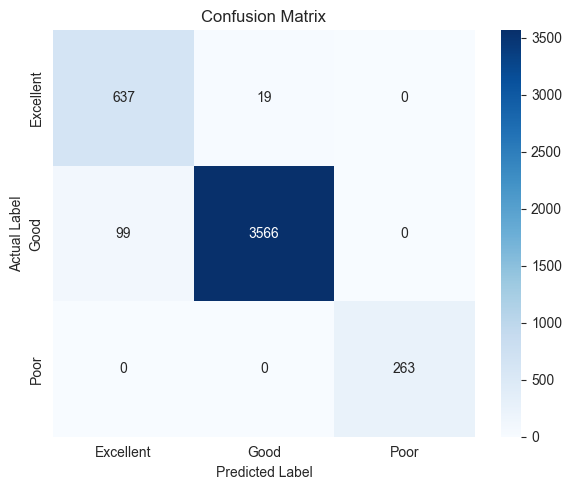

In [11]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

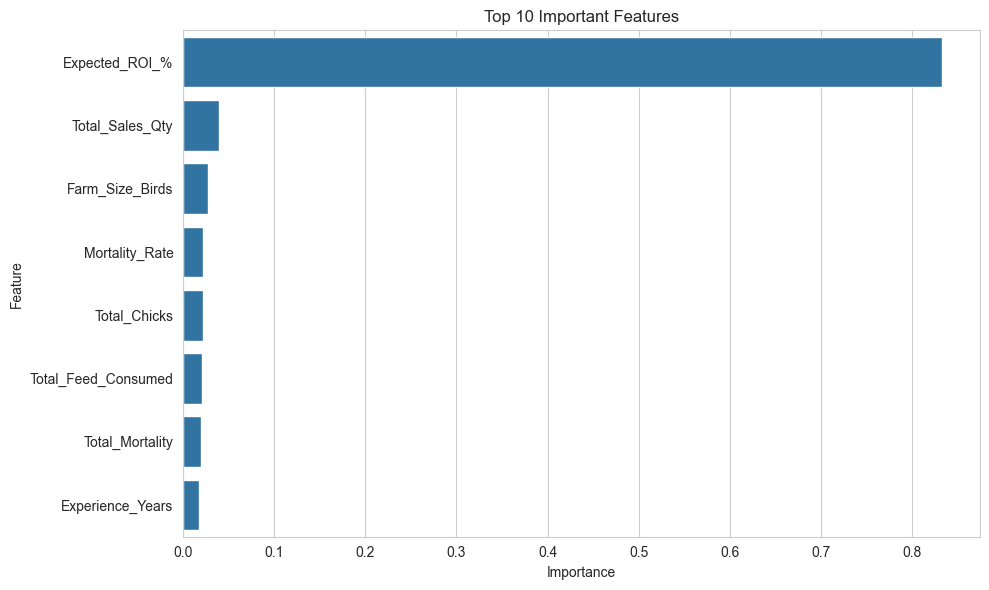

Top 10 Important Features:



,Feature,Importance
6,Expected_ROI_%,0.832919
5,Total_Sales_Qty,0.039769
0,Farm_Size_Birds,0.026763
7,Mortality_Rate,0.021932
2,Total_Chicks,0.021385
4,Total_Feed_Consumed,0.021168
3,Total_Mortality,0.019066
1,Experience_Years,0.016998


In [12]:
# ============================================================
# Feature Importance
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.tight_layout()
plt.show()

print("Top 10 Important Features:\n")

display(feature_importance.head(10))

### Insight

The most important features have the greatest influence on predicting farm performance and provide valuable business insights for farm management.

In [13]:
# ============================================================
# Final Evaluation
# ============================================================

print("="*60)
print("Final Model Performance")
print("="*60)

print(f"Model      : {best_model.__class__.__name__}")
print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")

Final Model Performance
Model      : RandomForestClassifier
Accuracy   : 0.9743
Precision  : 0.9765
Recall     : 0.9743
F1 Score   : 0.9749


In [14]:
# ============================================================
# Save Final Model
# ============================================================

import joblib

# Save trained Random Forest model
joblib.dump(best_model, "../models/farm_performance.pkl")

# Save Label Encoder
joblib.dump(le, "../models/label_encoder.pkl")

# Save Feature Names
joblib.dump(X.columns.tolist(), "../models/farm_feature_columns.pkl")

print("Farm Performance Model saved successfully.")
print("Model Path : ../models/farm_performance.pkl")

Farm Performance Model saved successfully.
Model Path : ../models/farm_performance.pkl


# Notebook Conclusion

In this notebook:

- Loaded the feature-engineered dataset.
- Compared four classification models.
- Selected Random Forest as the best-performing model.
- Applied hyperparameter tuning.
- Evaluated the final model using multiple metrics.
- Visualized model performance using ROC Curve, Confusion Matrix, and Feature Importance.
- Saved the trained model for deployment.

The trained Farm Performance model is now ready for prediction and integration into the application.